In [115]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

All imports OK
/home/govind/.local/lib/python3.10/site-packages/numpy/__init__.py
/home/govind/.local/lib/python3.10/site-packages/matplotlib/pyplot.py


In [196]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
import stellate
import importlib
importlib.reload(stellate)
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)



0.0

In [197]:
stellate_0 = stellate.Stellate(0)

stell_comb_ic = h.IClamp(stellate_0.soma(0.5))
stell_comb_ic.dur = 1e9

time_dur = 12000

time_steps = int(time_dur / h.dt)
time_arr = np.arange(0,time_dur,h.dt)

input_amp = -3.1e-3
theta_amp = 1e-4
theta_freq = 10.0

initial_phase = 0.0
mean,std=0,1e-5

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
input_rec = h.Vector().record(stell_comb_ic._ref_amp)

nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)



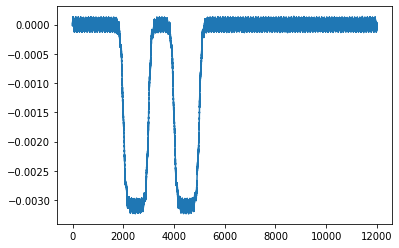

In [198]:
def input_func(t_ms):
    first_term = 0.5 * (np.tanh((t_ms - 2000)/100) - np.tanh((t_ms - 3000)/100))
    second_term = 0.5 * (np.tanh((t_ms - 4000)/100) - np.tanh((t_ms - 5000)/100))
    theta_term = theta_amp * np.sin(2 * np.pi * theta_freq * t_ms / 1000 + initial_phase)
    return (input_amp*(first_term + second_term)) + theta_term

noise_input = np.random.normal(0,std,time_steps)
stell_input = input_func(time_arr) + noise_input
plt.plot(time_arr,stell_input)
plt.show()

In [242]:
syn_inh = h.ExpSyn(stellate_0.soma(0.5))
syn_inh.e = -80 
syn_inh.tau = 0.01 
g_max = 0.005        
g_theta_amp = 1
theta_freq = 10.0    

def conductance_func(t_ms):
    
    pulse_1 = 0.5 * (np.tanh((t_ms - 2000)/200) - np.tanh((t_ms - 3500)/200)) + 0.0008
    pulse_2 = 0.5 * (np.tanh((t_ms - 8000)/200) - np.tanh((t_ms - 9500)/200)) + 0.0008
    envelope = pulse_1 + pulse_2
    
    oscillations = g_theta_amp*(np.sin(np.pi * theta_freq * t_ms / 1000 + initial_phase))**2
    
    return 10*g_max * envelope * (0.7 + 0.3 * oscillations)


stell_g_input = conductance_func(time_arr)
stell_g_input += np.random.normal(0, 1e-5, len(time_arr))
stell_g_input = np.clip(stell_g_input, 0, None)

g_vec = h.Vector(stell_g_input)
g_vec.play(syn_inh._ref_g, h.dt)


g_rec = h.Vector().record(syn_inh._ref_g)

h.finitialize(-65)
h.frecord_init()
h.continuerun(time_dur)



0.0

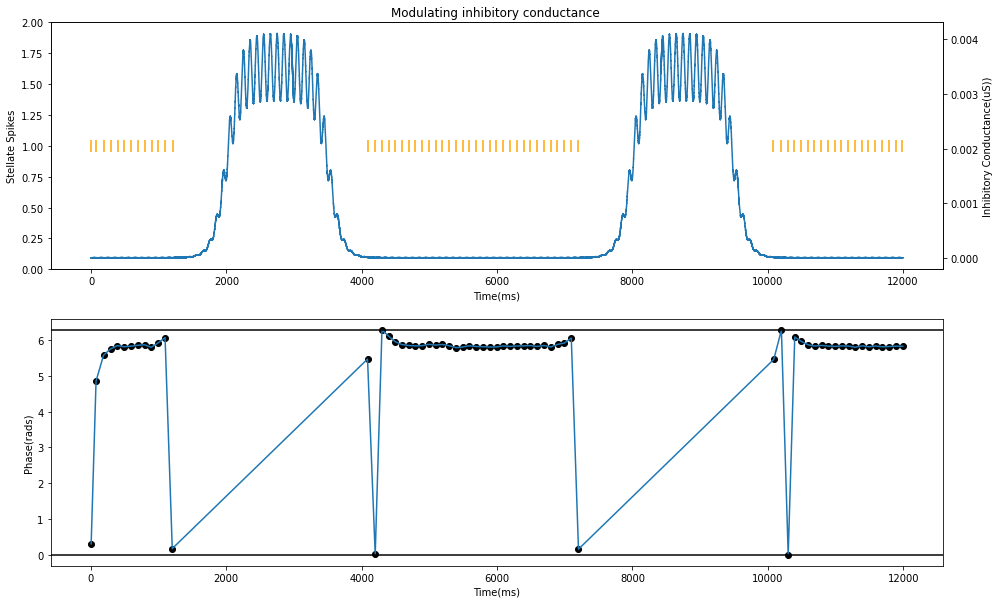

In [243]:
spike_times_array = np.array(spike_times_stell.to_python())
phases = (((spike_times_array) * theta_freq * 2 * np.pi / 1000)+initial_phase) % (2 * np.pi)
g_rec_array = np.array(g_rec.to_python())
fig,ax = plt.subplots(2,1,figsize=(16,10))
ax1=ax[0].twinx()
ax[0].eventplot(spike_times_array,label="Stellate Spikes",color='orange',linelengths=0.1)
ax[0].set_ylim(0,2)
ax1.plot(time,g_rec_array,label="Input")
ax[0].set_ylabel('Stellate Spikes')
ax1.set_ylabel('Inhibitory Conductance(uS))')
ax[0].set_xlabel('Time(ms)')
ax[1].plot(spike_times_array,phases)
ax[1].scatter(spike_times_array,phases,color='black')
ax[1].set_xlabel("Time(ms)")
ax[1].set_ylabel("Phase(rads)")
ax[1].axhline(y=2*np.pi,color='black')
ax[1].axhline(y=0,color='black')
ax[0].set_title("Modulating inhibitory conductance ")
plt.show()

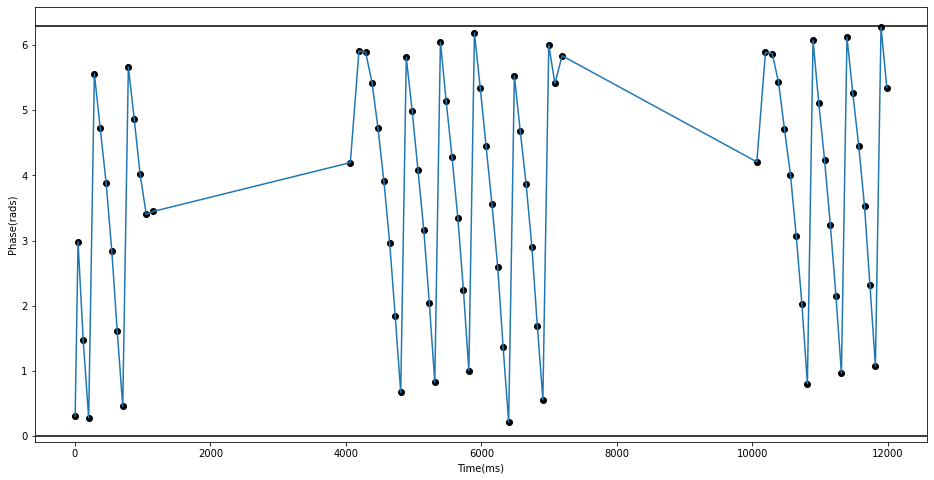